In [56]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
df = pd.read_csv("FINAL CSV-AIP 197.csv")

df.isna().sum()
df["datadate"] = pd.to_datetime(df["datadate"])
df.dtypes
df = df.dropna(subset=["emp", "revt", "ppent"])
df.shape
df["xrd"] = df["xrd"].fillna(0)
df["xrd"].isna().sum()
df = df[(df["emp"] > 0) & (df["revt"] > 0) & (df["at"] > 0)]
df["log_emp"] = np.log(df["emp"])
df["log_revenue"] = np.log(df["revt"])
df["log_assets"] = np.log(df["at"])
df[["emp","log_emp"]].head()
df["log_ai_patents"] = np.log1p(df["ai_patent_count"])
df["ai_patent_count"].describe()
df["ai_patent_count"].value_counts().head()
df["ai_patents_per_emp"] = df["ai_patent_count"] / df["emp"]
df["log_ai_patents_per_emp"] = np.log1p(df["ai_patents_per_emp"])


df[["ai_patent_count","log_ai_patents"]].head()
df["rd_intensity"] = df["xrd"] / df["emp"]
df["capital_intensity"] = df["ppent"] / df["emp"]
df["capx_intensity"] = df["capx"] / df["emp"]
df["ai_intensity"] = df["ai_patent_count"] / df["emp"]
df[["rd_intensity","capital_intensity","capx_intensity"]].describe(percentiles=[.01,.05,.95,.99])
for col in ["rd_intensity","capital_intensity","capx_intensity"]:
    df[col] = df[col].clip(df[col].quantile(.01), df[col].quantile(.99))
df[[
"log_emp",
"log_ai_patents",
"ai_intensity",
"rd_intensity",
"capital_intensity",
"capx_intensity"
]].describe()
summary_vars = [
"emp",
"ai_patent_count",
"rd_intensity",
"capital_intensity",
"capx_intensity"
]
df[summary_vars].describe()
df["naics2"] = df["naics"].astype(str).str[:2]
df.groupby("fyear")["gvkey"].nunique()
df["naics2"].value_counts()

df.groupby("fyear")["gvkey"].count()
df = df.dropna(subset=[
    "log_emp",
    "log_ai_patents",
    "rd_intensity",
    "capital_intensity",
    "capx_intensity"
])

X = df[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]


print(X.isna().sum())
print(np.isinf(X).sum())

summary_vars = [
    "emp",
    "ai_patent_count",
    "rd_intensity",
    "capital_intensity",
    "capx_intensity"
]

summary_stats = df[summary_vars].describe()
print(summary_stats)

log_emp              0
rd_intensity         0
capital_intensity    0
capx_intensity       0
dtype: int64
log_emp              0
rd_intensity         0
capital_intensity    0
capx_intensity       0
dtype: int64
          emp  ai_patent_count  rd_intensity  capital_intensity  \
count 817.000          817.000       817.000            817.000   
mean   49.890            6.010        83.545            123.316   
std    94.202           14.880        82.404            157.334   
min     0.006            1.000         0.000              7.327   
25%     3.400            1.000        24.051             43.925   
50%    12.985            2.000        62.530             71.524   
75%    56.194            4.000       117.021            123.587   
max   671.687          135.000       414.181            975.658   

       capx_intensity  
count         817.000  
mean           27.307  
std            39.890  
min             0.000  
25%             7.327  
50%            14.574  
75%            28.

In [57]:
##ACTUAL REGRESSION
model1 = smf.ols(
    "log_ai_patents ~ log_emp",
    data=df
).fit(cov_type="HC3")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     97.45
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           8.67e-22
Time:                        14:57:22   Log-Likelihood:                -1004.1
No. Observations:                 817   AIC:                             2012.
Df Residuals:                     815   BIC:                             2022.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9428      0.030     31.072      0.0

In [58]:
###Regression with controls
model2 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity",
    data=df
).fit(cov_type="HC3")

print(model2.summary())

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["log_emp","rd_intensity","capital_intensity","capx_intensity"]]
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
print(vif)

                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     39.57
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.67e-30
Time:                        14:57:22   Log-Likelihood:                -936.77
No. Observations:                 817   AIC:                             1884.
Df Residuals:                     812   BIC:                             1907.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.4565      0.06

In [59]:
##fixed regression

model3 = smf.ols(
    "log_ai_patents ~ log_emp + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="HC3")

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     7.728
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.24e-33
Time:                        14:57:22   Log-Likelihood:                -883.32
No. Observations:                 817   AIC:                             1843.
Df Residuals:                     779   BIC:                             2021.
Df Model:                          37                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.2503      0.70

In [60]:
df["log_emp_sq"] = df["log_emp"]**2
model4 = smf.ols(
    "log_ai_patents ~ log_emp + log_emp_sq + rd_intensity + capital_intensity + capx_intensity + C(naics2) + C(fyear)",
    data=df
).fit(cov_type="HC3")

print(model4.summary())


                            OLS Regression Results                            
Dep. Variable:         log_ai_patents   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     8.165
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           3.49e-36
Time:                        14:57:22   Log-Likelihood:                -862.57
No. Observations:                 817   AIC:                             1803.
Df Residuals:                     778   BIC:                             1987.
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -1.3675      0.82

In [61]:
from statsmodels.iolib.summary2 import summary_col
summary = summary_col([model1, model2, model3, model4])
print(summary)



                  log_ai_patents I log_ai_patents II log_ai_patents III log_ai_patents IIII
-------------------------------------------------------------------------------------------
Intercept         0.9428           0.4565            -1.2503            -1.3675            
                  (0.0303)         (0.0609)          (0.7008)           (0.8243)           
log_emp           0.1474           0.1887            0.2183             0.1068             
                  (0.0149)         (0.0176)          (0.0214)           (0.0181)           
rd_intensity                       0.0035            0.0031             0.0033             
                                   (0.0005)          (0.0005)           (0.0005)           
capital_intensity                  0.0004            0.0001             -0.0002            
                                   (0.0005)          (0.0005)           (0.0005)           
capx_intensity                     0.0017            0.0032             0.0038 

In [63]:
mean_log_emp = df["log_emp"].mean()

beta1 = model4.params["log_emp"]
beta2 = model4.params["log_emp_sq"]

marginal_effect = beta1 + 2 * beta2 * mean_log_emp

print("Marginal effect:", marginal_effect)

Marginal effect: 0.2772491454123118


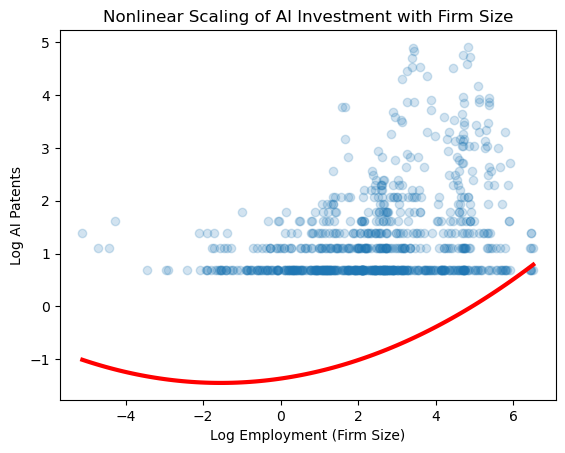

In [62]:


x = np.linspace(df["log_emp"].min(), df["log_emp"].max(), 100)

y = (
    model4.params["Intercept"]
    + model4.params["log_emp"] * x
    + model4.params["log_emp_sq"] * x**2
)

plt.scatter(df["log_emp"], df["log_ai_patents"], alpha=0.2)
plt.plot(x, y, color="red", linewidth=3)

plt.xlabel("Log Employment (Firm Size)")
plt.ylabel("Log AI Patents")
plt.title("Nonlinear Scaling of AI Investment with Firm Size")

plt.show()